In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import matplotlib.pyplot as plt
%matplotlib inline

import torch.nn.functional as F
import random

In [79]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [80]:
chars = sorted(list(set(''.join(words))))
mapp = {s:i+1 for i,s in enumerate(chars)}
mapp['.'] = 0
invmap = {i:s for s,i in mapp.items()}

In [81]:
block_size = 3
def build_dataset(words, bs):
    block_size = bs
    X,Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = mapp[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(invmap[i] for i in context), ' --> ', invmap[ix])
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(222)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xtst, Ytst = build_dataset(words[n2:], block_size)

In [82]:
#to check correctness by comp out manual grad calculation wrt pytorch grad 
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f"{s:15s} | exact: {str(ex):5s} | approx: {str(app):5s} | maxdiff: {maxdiff}")

In [83]:
#b1 is useless cause in hout - hout.mean() b1 cancels out since constant added value in mean gives that value back only hence cancels. So remove it

In [84]:
embspace = 10
n_hidden = 200

g = torch.Generator().manual_seed(222)
C = torch.randn((27, embspace), generator=g)
W1 = torch.randn((embspace*block_size, n_hidden), generator=g)  *((embspace*block_size)**(0.5)) #this is from research paper 
b1 = torch.randn(n_hidden, generator=g) * 0.1
W2 = torch.randn((n_hidden, 27), generator=g) * 0.1
b2 = torch.randn(27, generator=g) * 0.1

bngain = torch.ones((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.zeros((1, n_hidden))*0.1
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [85]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch
    mb = torch.randint(0, Xtr.shape[0], (batch_size,)) # selects random 32 rows from X 
    Xb = Xtr[mb]
    Yb = Ytr[mb]
    
    #Forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],embspace*block_size)
    hout = embcat @ W1 + b1
    
    #hout dimesnions are 32X30 so mean was 1/32 * sum of the ith column for each column (feature we normalize it seprately) not row but feature wise mean we take and normalize
    #since tanh kills very neg and ver pos values we will normalize it and make it roughly gaussion 
    bnmean = 1/batch_size * hout.sum(0, keepdim = True)
    bndiff = hout - bnmean
    bndiffsq = bndiff ** 2
    bnvar = 1/(batch_size-1) * bndiffsq.sum(0, keepdim=True)
    bnstd_inv = (bnvar + 1e-5) ** (-0.5)
    hraw = bndiff * bnstd_inv
    
    #now problem with always forcing it to be gaussian is it creates very similarities between diff neurons of a layer so dead neurons so we give soem bias and gaain to it
    hcal = bngain*hraw + bnbias

    # with torch.no_grad():
    #     bnmean_running = 0.999 * bnmean_running + 0.001*bnmean
    #     bnstd_running = 0.999 * bnstd_running + 0.001*bnstd
    
    h = torch.tanh(hcal)
    logits = h@W2 + b2
    
    # loss = F.cross_entropy(logits, Yb)
    #so to normalize we for each exmaple ir each row we slect mmax in taht row and sub to all elemnts in that row
    logit_maxes = logits.max(1, keepdim=True).values
    norm_logits = logits - logit_maxes
    counts = norm_logits.exp()
    counts_sum = counts.sum(1, keepdim=True)
    counts_sum_inv = counts_sum ** (-1)
    probs= counts * counts_sum_inv
    logprobs = probs.log()
    loss = -logprobs[range(batch_size), Yb].mean()

    lossi.append(loss.log10().item())
    if(i)%20000 == 0:
        print(loss.item())
        
    #backward pass
    for p in parameters:
        p.grad = None
        
    ####################################       manual loss.backward()   ##########################################################
    dlogprobs = torch.zeros_like(logprobs)
    dlogprobs[range(batch_size), Yb] = -1.0/batch_size
    dprobs = dlogprobs * (probs)**(-1)
    dcounts_sum_inv = (dprobs * counts).sum(1, keepdim=True)
    dcounts_sum = dcounts_sum_inv * (-counts_sum ** -2)
    dcounts = counts_sum_inv * dprobs + dcounts_sum * torch.ones_like(counts)
    dnorm_logits = dcounts * counts
    dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
    dlogits = dnorm_logits.clone()
    temp = torch.zeros_like(logits)
    temp[range(batch_size), logits.max(1).indices] = 1
    dlogits += temp * dlogit_maxes
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    dhcal = (1.0 - h**2) * dh
    dbngain = (dhcal * hraw).sum(0, keepdim=True)
    dbnbias = dhcal.sum(0, keepdim=True)
    dhraw = dhcal * bngain
    dbnstd_inv = (dhraw * bndiff).sum(0, keepdim=True)
    dbnvar = (-0.5 * bnvar**(-1.5)) * dbnstd_inv
    dbndiffsq = dbnvar * (1/(batch_size - 1)) * torch.ones_like(bndiffsq)
    dbndiff = dhraw * bnstd_inv + dbndiffsq * bndiff * 2
    dbnmean = -dbndiff.sum(0, keepdim=True)
    dhout = dbndiff + dbnmean * (1/batch_size) * torch.ones_like(hout)
    dembcat = dhout @ W1.T
    dW1 = embcat.T @ dhout
    db1 = dhout.sum(0)
    demb = dembcat.view(emb.shape) 
    dC= torch.zeros_like(C)
    dC.index_add_(0, Xb.view(-1), demb.view(-1, 10))
    #########################################################################################################################################
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    
    for p,grad in  zip(parameters, grads):
        p.data += -0.01 * grad

    #break

3.6896066665649414
1.9752308130264282
2.23931622505188
2.3606371879577637
2.042611837387085
2.0037848949432373
2.5514402389526367
2.467289686203003
2.233157157897949
2.5795974731445312


In [28]:
counts.shape, counts_sum_inv.shape

(torch.Size([32, 27]), torch.Size([32, 1]))

In [33]:
norm_logits.shape, logit_maxes.shape, logits.shape

(torch.Size([32, 27]), torch.Size([32, 1]), torch.Size([32, 27]))

(<matplotlib.image.AxesImage at 0x220d959cb90>, torch.Size([32, 27]))

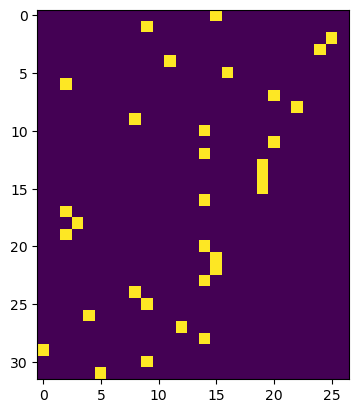

In [45]:
temp = torch.zeros_like(logits)
temp[range(batch_size), logits.max(1).indices] = 1
plt.imshow(temp), temp.shape

In [49]:
h.shape, W2.shape, b2.shape, dlogits.shape

(torch.Size([32, 200]),
 torch.Size([200, 27]),
 torch.Size([27]),
 torch.Size([32, 27]))

In [53]:
hcal.shape, bngain.shape, hraw.shape, bnbias.shape

(torch.Size([32, 200]),
 torch.Size([1, 200]),
 torch.Size([32, 200]),
 torch.Size([1, 200]))

In [58]:
dbngain = (dhcal * hraw).sum(0, keepdim=True)
dbngain.shape

torch.Size([1, 200])

In [59]:
dbngain = (dhcal * hraw).sum(0)
dbngain.shape

torch.Size([200])

In [63]:
hraw.shape, bndiff.shape, bnstd_inv.shape, bndiffsq.shape, bnvar.shape

(torch.Size([32, 200]),
 torch.Size([32, 200]),
 torch.Size([1, 200]),
 torch.Size([32, 200]),
 torch.Size([1, 200]))

In [65]:
bnmean.shape, bndiff.shape, hout.shape

(torch.Size([1, 200]), torch.Size([32, 200]), torch.Size([32, 200]))

In [66]:
hout.shape, embcat.shape, W1.shape, b1.shape

(torch.Size([32, 200]),
 torch.Size([32, 30]),
 torch.Size([30, 200]),
 torch.Size([200]))

In [69]:
emb.shape, C.shape, Xb.shape

(torch.Size([32, 3, 10]), torch.Size([27, 10]), torch.Size([32, 3]))

In [70]:
#manual calculations of derivatives of the functions

#1. dloss/dlogprob for each of logprob like for each nodes in(32,27) in tree the grad is either -1/n or 0. zero cause in logprobs.sum we only consider 1 elemnt from each row so other grad is 0
#    and dloss/da1 where a1 is that one elemnt which we considered is nothing but -1/n where n is batch_size cause loss = -(a1 + a2 +...+ a32)/n
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(batch_size), Yb] = -1.0/batch_size

#2. logprobs = log(probs) so dlogprobs/dprobs = 1/probs and dloss/dprobs = multiply this deriv with previous deriv
dprobs = dlogprobs * (probs)**(-1)

#3. dprobs/dcounts_sum_inc = counts
#    counts dim = 32,27 and csi = 32,1 so if we wirte it mor eopenly then
#    csi2 = (csi,csi,csi,...27 times) = csi * 27 along columns then probs = csi2 * counts
#    so csi2.grad = (dprobs * counts) which is 32,27 and we want 32,1 so its either (dprobs*counts)[:][0] * 27 (dcsi2/dcsi = 27) or its same to sum of each row which we did below
dcounts_sum_inv = (dprobs * counts).sum(1, keepdim=True)

#4. dc_s_i/dc_s = 1/c_s^2
dcounts_sum = dcounts_sum_inv * (-counts_sum ** -2)

#5. dloss/dcounts = dloss/dprobs * (dprobs/dcounts = coutns_sum_inv)
#   dloss/dcounts += dloss/dcounts_sum * (dcounts_sum/dcounts = 1)
dcounts = counts_sum_inv * dprobs + dcounts_sum * torch.ones_like(counts)

#6. counts = e^n_l  dcounts/dn_l = e^n_l = counts
dnorm_logits = dcounts * counts

#6.5 logit_maxes_2 = (logit_maxes,...,logit_maxes) then norm_logits = ... - logit_maxes_2 so dn_l/dl_m_2 = -1 and dl_m_2/dl_m = 27 so either of two options like before
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)

#7. dn_l/dl = 1 + dl_m/dl = now here we pick one maxi elemnt form each row, rem deriv is 0 and for max picked value deriv should be 1 so below is that written
dlogits = dnorm_logits.clone()
temp = torch.zeros_like(logits)
temp[range(batch_size), logits.max(1).indices] = 1
dlogits += temp * dlogit_maxes

#8.dlogits/dh = W2, dloss/dh = (dlogits/dh)T @ dloss/dlogits. we need transpose in derievative try it out on simple example like 2X2 matrix and differentiate it
dh = dlogits @ W2.T

#9. dlogits/dW2= h 
dW2 = h.T @ dlogits

#10. bnew2 = (b2)T repeated row wise liek horizontaly stacked up then logits = ... + bnew2 so dlogits/dbnew2 = 1 dim 32X27 then dbnew2/db2 = 32 * (b2)T this time each column is added up dim is 1X27
db2 = dlogits.sum(0)

#11. h = tanh(hcal). dh/dhcal = 1 - tanh(hcal)^2
dhcal = (1.0 - h**2) * dh

#12. dhcal/dbngain = hraw. see dimensions like multiply hraw * dhcal and then squixh it the sum(0) upon columns down to 1 row 
dbngain = (dhcal * hraw).sum(0, keepdim=True)

#13.dhcal/dbnbias = 1 so just see dimensions and guess ig :) you understand diff idea and then to write it see what and how and hwere to squish things up and when to keepdim
dbnbias = dhcal.sum(0, keepdim=True)

#14. dhcal/dhraw = bngain.here its ismple multiply it will handle on own
dhraw = dhcal * bngain

#15. dhraw/dbnstd_inv = bndiff. multiply simply and squish it up
dbnstd_inv = (dhraw * bndiff).sum(0, keepdim=True)

#16. dbnstd_inv/dbnvar = -0.5 * bnvar**(-1.5)
dbnvar = (-0.5 * bnvar**(-1.5)) * dbnstd_inv

#17. similar to counts wrt counts_sum
dbndiffsq = dbnvar * (1/(batch_size - 1)) * torch.ones_like(bndiffsq)

#18. dhraw/dbndiff  = bnstd_inv + dbndiffsq/dbndiff =  2 * bndiff
dbndiff = dhraw * bnstd_inv + dbndiffsq * bndiff * 2

#19. dbndiff/dbnmean = -1
dbnmean = -dbndiff.sum(0, keepdim=True)

#20. dbndiff/dhout = 1 + dbnmean/dhout = below (think-harder!)
dhout = dbndiff + dbnmean * (1/batch_size) * torch.ones_like(hout)

#21. dhout/dembcat = W1
dembcat = dhout @ W1.T

#22. dhout/dw1 = embcat
dW1 = embcat.T @ dhout

#23. dhout/db1 = 1
db1 = dhout.sum(0)

#24. just view of dembcat in emb.shape like it was just flatened now reverse it derievatives would not change
demb = dembcat.view(emb.shape) 


#25. Hard! So C contains for all 27 characters their position/coordinates in 10-D now those char which came in Xb like it have 32*3 chars so the char which did not came
#         have grad = 0 and those came have grad demb[pos on Xb] and that also keep on adding according to what number of times they came
dC= torch.zeros_like(C)
for i in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ch = Xb[i,j]
    dC[ch] += demb[i,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hcal', dhcal, hcal)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('hraw', dhraw, hraw)
cmp('bnstd_inv', dbnstd_inv, bnstd_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiffsq, bndiffsq)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmean', dbnmean, bnmean)
cmp('hout', dhout, hout)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approx: True  | maxdiff: 0.0
probs           | exact: True  | approx: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approx: True  | maxdiff: 0.0
counts_sum      | exact: True  | approx: True  | maxdiff: 0.0
counts          | exact: True  | approx: True  | maxdiff: 0.0
norm_logits     | exact: True  | approx: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approx: True  | maxdiff: 0.0
logits          | exact: True  | approx: True  | maxdiff: 0.0
h               | exact: True  | approx: True  | maxdiff: 0.0
W2              | exact: True  | approx: True  | maxdiff: 0.0
b2              | exact: True  | approx: True  | maxdiff: 0.0
hcal            | exact: True  | approx: True  | maxdiff: 0.0
bngain          | exact: True  | approx: True  | maxdiff: 0.0
bnbias          | exact: True  | approx: True  | maxdiff: 0.0
hraw            | exact: True  | approx: True  | maxdiff: 0.0
bnstd_inv       | exact: True  | approx: True  | maxdiff: 0.0
bnvar   

In [86]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hcal = embcat @ W1 + b1
  bnmean = hcal.mean(0, keepdim=True)
  bnvar = hcal.var(0, keepdim=True, unbiased=True)

In [87]:
Xs = [Xtr, Xdev, Xtst]
Ys = [Ytr, Ydev, Ytst]

@torch.no_grad()
def func():
    for x,y in zip(Xs, Ys):
        emb = C[x]
        emb = emb.view(emb.shape[0], embspace*block_size)
        hout = emb @ W1 + b1
        hout = (hout - bnmean) * (bnvar + 1e-5)**-0.5
        hout = bngain*hout + bnbias
        h = torch.tanh(hout)
        logits = h@W2 + b2
        loss = F.cross_entropy(logits, y)
        print(f"-tr/dev/tst: {loss.item()}")

func()

-tr/dev/tst: 2.2098886966705322
-tr/dev/tst: 2.226085901260376
-tr/dev/tst: 2.218522310256958


In [88]:
# Sampling from the neural network
g = torch.Generator().manual_seed(222)

for _ in range(20):
    out = []
    context = [0] * block_size 
    
    while True:
        emb = C[torch.tensor([context])]
        emb = emb.view(1, 30)
        hout = emb @ W1 + b1
        hout = (hout - bnmean) * (bnvar + 1e-5)**-0.5
        hout = bngain*hout + bnbias
        h = torch.tanh(hout)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break

    print(''.join(invmap[i] for i in out))

nexichikalfyro.
damancid.
hayberanavyahlynn.
lupa.
jalis.
vind.
emie.
jaylean.
tce.
zach.
alia.
zulanie.
hon.
kenia.
mari.
jamiah.
jaishanna.
wackerlen.
coru.
kailinacezinis.
